# Text Clustering

## Goal
Group similar documents together without any labels.
Unsupervised learning — the model finds structure on its own.

## Approach
TF-IDF for feature extraction
K-Means for clustering
PCA for visualization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## 1. Define Documents
12 documents across 3 topics: ML, Climate, Cooking.
The model does not know the labels — it has to discover the groups.

In [2]:
documents = [
    # ML (0)
    "Machine learning enables computers to learn from data",
    "Deep learning uses neural networks with many layers",
    "Training a model requires large amounts of labeled data",
    "Gradient descent optimizes the loss function during training",
    # Climate (1)
    "Climate change is causing glaciers to melt worldwide",
    "Renewable energy can reduce carbon emissions significantly",
    "Rising sea levels threaten coastal cities around the world",
    "Solar and wind power are sustainable energy sources",
    # Cooking (2)
    "Fresh ingredients always produce better tasting dishes",
    "Temperature control is crucial when baking bread",
    "Understanding food chemistry helps create better recipes",
    "Proper knife skills are essential in professional cooking",
]

true_labels = [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2]
label_names = {0: "ML", 1: "Climate", 2: "Cooking"}

print(f"Total documents: {len(documents)}")
print(f"Topics: {list(label_names.values())}")

Total documents: 12
Topics: ['ML', 'Climate', 'Cooking']


## 2. Vectorize and Cluster

In [4]:
# Vectorize
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(documents)

# K-maens clusternig
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
predicted_labels = kmeans.fit_predict(tfidf_matrix)

# Results
print(f"{'Document':<50} {'True':>8} {'Predicted':>10}")
print("-" * 70)
for doc, true, pred in zip(documents,true_labels, predicted_labels):
    match = "✓" if true == pred else "x"
    print(f"{doc[:48]:<50} {label_names[true]:>8} {pred:>10} {match}")

Document                                               True  Predicted
----------------------------------------------------------------------
Machine learning enables computers to learn from         ML          2 x
Deep learning uses neural networks with many lay         ML          2 x
Training a model requires large amounts of label         ML          2 x
Gradient descent optimizes the loss function dur         ML          0 ✓
Climate change is causing glaciers to melt world    Climate          0 x
Renewable energy can reduce carbon emissions sig    Climate          1 ✓
Rising sea levels threaten coastal cities around    Climate          0 x
Solar and wind power are sustainable energy sour    Climate          1 ✓
Fresh ingredients always produce better tasting     Cooking          0 x
Temperature control is crucial when baking bread    Cooking          0 x
Understanding food chemistry helps create better    Cooking          0 x
Proper knife skills are essential in professiona    Coo

## 3. Visualize Clusters with PCA
Labels don't matter - let's see if the clusters are actually separated.

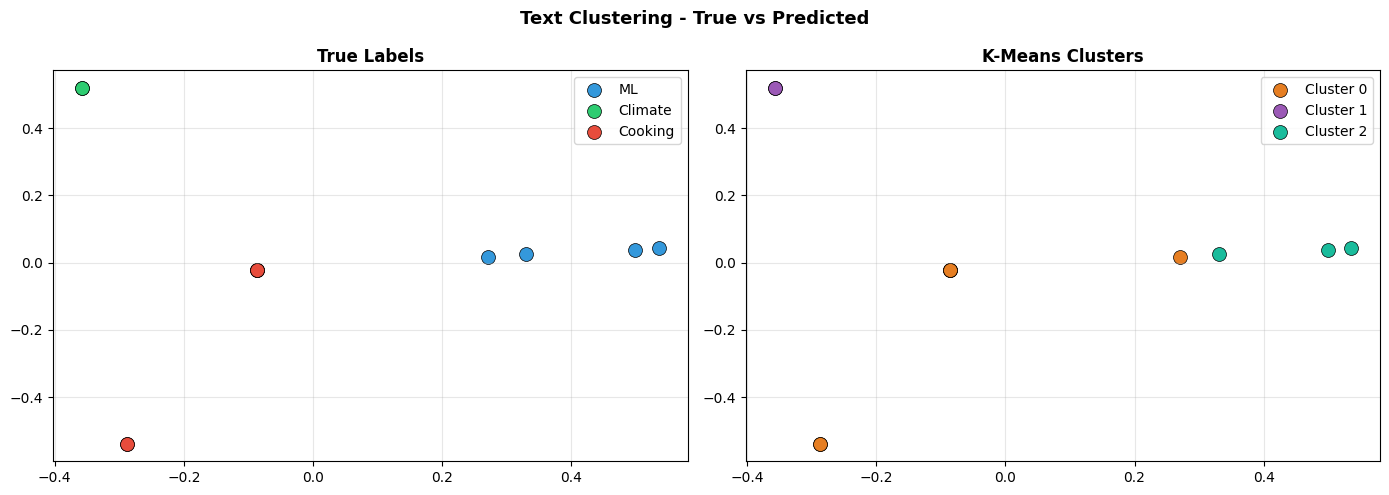

In [8]:
# Reduce to 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(tfidf_matrix.toarray())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_true = ["#3498db", "#2ecc71", "#e74c3c"]
colors_pred = ["#e67e22", "#9b59b6", "#1abc9c"]

# True labels
for label, name, color in zip([0, 1, 2], label_names.values(), colors_true):
    mask = [i for i, l in enumerate(true_labels) if l == label]
    axes[0].scatter(vectors_2d[mask, 0], vectors_2d[mask, 1],
                  c=color, label=name, s=100, edgecolors="black", linewidth=0.5)

axes[0].set_title("True Labels", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predicted clusters
for cluster in range(3):
    mask = [i for i, l in enumerate(predicted_labels) if l == cluster]
    axes[1].scatter(vectors_2d[mask, 0], vectors_2d[mask, 1],
                   c=colors_pred[cluster], label=f"Cluster {cluster}",
                   s=100, edgecolors='black', linewidth=0.5)


axes[1].set_title("K-Means Clusters", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Text Clustering - True vs Predicted", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("text_clustering.png", dpi=300)
plt.show()

## 4. Key Observations

## Why Did Clustering Fail?

- Corpus is too small — 12 documents, very sparse TF-IDF vectors
- Documents share few words across topics
- TF-IDF cannot capture semantic similarity
  "neural networks" and "deep learning" have no shared words

## What the Plot Shows
Points are not well separated in 2D space.
TF-IDF vectors in high dimensions collapse to similar positions after PCA.
K-Means cannot find meaningful boundaries.

## Key Insight
Text clustering with TF-IDF works better with:
- Larger corpus (hundreds of documents)
- Longer documents (more word overlap)
- Preprocessing (removing stopwords, lemmatization)

For small corpora, sentence embeddings (SBERT) produce
much better clusters because they capture meaning, not just word overlap.

## Takeaway
A failure is more informative than a success.
This experiment shows exactly where TF-IDF breaks down
and why embeddings were invented.